IMPORT LIBRARIES

In [1]:
import sys
!{sys.executable} -m pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


In [1]:
import xgboost
print(xgboost.__version__)

3.2.0


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    average_precision_score, roc_auc_score, brier_score_loss,
    precision_score, recall_score, f1_score
)

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

LOAD DATA


In [6]:
import pandas as pd

df = pd.read_csv(r"C:\Users\ARTHI\Downloads\data.csv")

print("Shape:", df.shape)

print("\nTarget distribution:")
print(df['Bankrupt?'].value_counts(normalize=True))

df.head()

Shape: (6819, 96)

Target distribution:
Bankrupt?
0    0.967737
1    0.032263
Name: proportion, dtype: float64


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


QUICK EDA

Missing values:
 0
Duplicates: 0


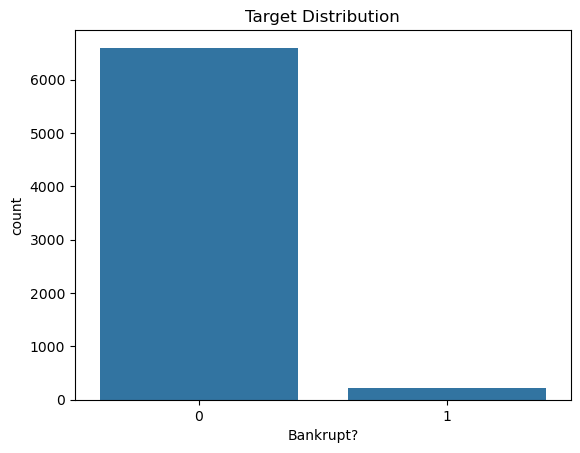

In [7]:
print("Missing values:\n", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

sns.countplot(x='Bankrupt?', data=df)
plt.title("Target Distribution")
plt.show()

SPLIT DATA (70/15/15)

In [8]:
X = df.drop('Bankrupt?', axis=1)
y = df['Bankrupt?']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Train:", y_train.mean())
print("Val:", y_val.mean())
print("Test:", y_test.mean())

Train: 0.03226482296249738
Val: 0.03225806451612903
Test: 0.03225806451612903


PREPROCESSING

In [9]:
# Fill missing values (simple approach)
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)
X_test = X_test.fillna(0)

EVALUATION FUNCTION 

In [10]:
def evaluate_model(model, X_train, y_train, X_val, y_val, threshold=0.5):
    
    model.fit(X_train, y_train)
    
    # Probabilities
    train_probs = model.predict_proba(X_train)[:,1]
    val_probs = model.predict_proba(X_val)[:,1]
    
    # Predictions
    val_preds = (val_probs >= threshold).astype(int)
    
    # Metrics
    results = {}
    results['train_pr_auc'] = average_precision_score(y_train, train_probs)
    results['val_pr_auc'] = average_precision_score(y_val, val_probs)
    results['val_roc_auc'] = roc_auc_score(y_val, val_probs)
    results['val_brier'] = brier_score_loss(y_val, val_probs)
    
    results['val_precision'] = precision_score(y_val, val_preds)
    results['val_recall'] = recall_score(y_val, val_preds)
    results['val_f1'] = f1_score(y_val, val_preds)
    
    results['overfit_gap'] = results['train_pr_auc'] - results['val_pr_auc']
    
    return results, model

FEATURE SET A (ALL FEATURES)

In [11]:
X_train_A = X_train.copy()
X_val_A = X_val.copy()

FEATURE SET B (TOP FEATURES)

In [12]:
temp_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
temp_model.fit(X_train_A, y_train)

importances = temp_model.feature_importances_
features = X_train_A.columns

feat_imp = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

top_features = feat_imp.head(25)['feature'].tolist()

X_train_B = X_train_A[top_features]
X_val_B = X_val_A[top_features]
X_test_B = X_test[top_features]

c:\Users\ARTHI\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:06:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


5 EXPERIMENTS

Logistic Regression (Baseline)

In [13]:
model1 = LogisticRegression(max_iter=1000)

res1, model1 = evaluate_model(model1, X_train_A, y_train, X_val_A, y_val)

EXP 2: XGBoost Baseline

In [14]:
model2 = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

res2, model2 = evaluate_model(model2, X_train_A, y_train, X_val_A, y_val)

c:\Users\ARTHI\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:08:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


EXP 3: XGBoost with Imbalance Handling

In [15]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

model3 = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss'
)

res3, model3 = evaluate_model(model3, X_train_A, y_train, X_val_A, y_val)

c:\Users\ARTHI\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:09:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


EXP 4: XGBoost Tuned

In [16]:
model4 = XGBClassifier(
    max_depth=4,
    learning_rate=0.05,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss'
)

res4, model4 = evaluate_model(model4, X_train_A, y_train, X_val_A, y_val)

c:\Users\ARTHI\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:10:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


EXP 5: XGBoost with Feature Set B

In [17]:
model5 = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

res5, model5 = evaluate_model(model5, X_train_B, y_train, X_val_B, y_val)

c:\Users\ARTHI\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:10:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RESULTS TABLE

In [18]:
results = pd.DataFrame([
    ['1','Logistic','A',res1],
    ['2','XGB Base','A',res2],
    ['3','XGB Imbalance','A',res3],
    ['4','XGB Tuned','A',res4],
    ['5','XGB Small','B',res5]
], columns=['exp_id','model','feature_set','metrics'])

results = pd.concat([results.drop(['metrics'], axis=1), results['metrics'].apply(pd.Series)], axis=1)

results

,exp_id,model,feature_set,train_pr_auc,val_pr_auc,val_roc_auc,val_brier,val_precision,val_recall,val_f1,overfit_gap
0,1,Logistic,A,0.061061,0.043408,0.586563,0.043268,0.000000,0.000000,0.000000,0.017653
1,2,XGB Base,A,1.000000,0.488890,0.952709,0.023819,0.625000,0.303030,0.408163,0.511110
2,3,XGB Imbalance,A,1.000000,0.494488,0.958157,0.023838,0.545455,0.363636,0.436364,0.505512
3,4,XGB Tuned,A,0.999958,0.587225,0.962045,0.019781,0.692308,0.272727,0.391304,0.412733
4,5,XGB Small,B,1.000000,0.413627,0.924089,0.025145,0.529412,0.272727,0.360000,0.586373


FINAL TEST EVALUATION

In [19]:
final_model = model4

# Choose threshold
threshold = 0.3

test_probs = final_model.predict_proba(X_test)[:,1]
test_preds = (test_probs >= threshold).astype(int)

print("Test PR-AUC:", average_precision_score(y_test, test_probs))
print("Test ROC-AUC:", roc_auc_score(y_test, test_probs))
print("Test Brier:", brier_score_loss(y_test, test_probs))
print("Precision:", precision_score(y_test, test_preds))
print("Recall:", recall_score(y_test, test_preds))
print("F1:", f1_score(y_test, test_preds))

Test PR-AUC: 0.5005824372300658
Test ROC-AUC: 0.9532292623201715
Test Brier: 0.022555007286634024
Precision: 0.5
Recall: 0.45454545454545453
F1: 0.47619047619047616


CONFUSION MATRIX

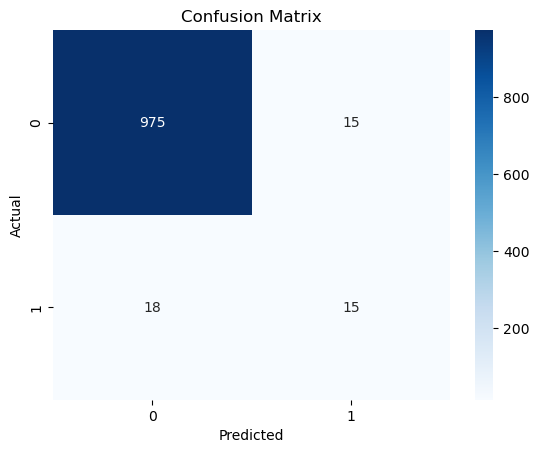

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, test_preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

FEATURE IMPORTANCE

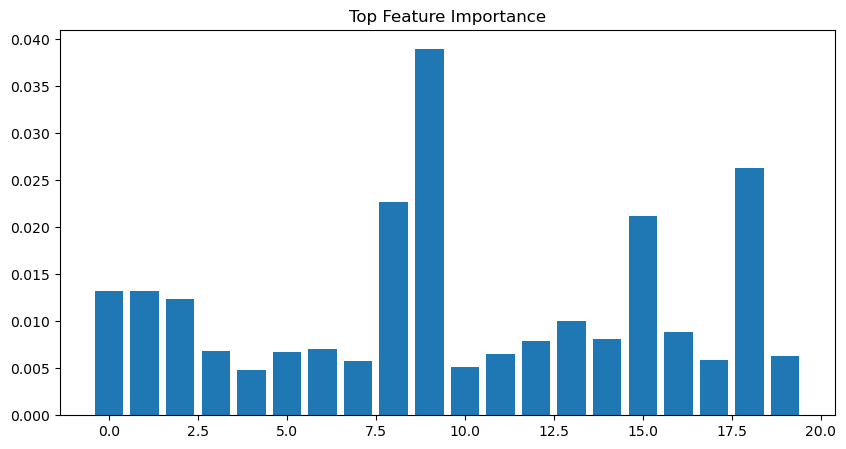

In [21]:
import matplotlib.pyplot as plt

importances = final_model.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(range(len(importances[:20])), importances[:20])
plt.title("Top Feature Importance")
plt.show()